In [81]:
#importing the necessary libraries
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv("C:/Projects/Twitter Sentiment Analyzer/tweet-sentiment-analyzer/data/raw/Tweets.csv")

In [6]:
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [16]:
#checking the structure of the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  str    
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   str    
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  str    
 6   airline_sentiment_gold        40 non-null     str    
 7   name                          14640 non-null  str    
 8   negativereason_gold           32 non-null     str    
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  str    
 11  tweet_coord                   1019 non-null   str    
 12  tweet_created                 14640 non-null  str    
 13  tweet_locati

In [27]:
print("No:of rows=",df.shape[0])
print("No:of features=",df.shape[1])

No:of rows= 14640
No:of features= 15


In [28]:
#checking the missing values in each columns
df.isna().sum().sort_values(ascending=False)

negativereason_gold             14608
airline_sentiment_gold          14600
tweet_coord                     13621
negativereason                   5462
user_timezone                    4820
tweet_location                   4733
negativereason_confidence        4118
airline                             0
tweet_id                            0
airline_sentiment                   0
airline_sentiment_confidence        0
text                                0
retweet_count                       0
name                                0
tweet_created                       0
dtype: int64

In [207]:
#checking duplicates
df.duplicated().sum()

np.int64(36)

There are 36 duplicated rows

In [208]:
df.nunique().sort_values()

airline_sentiment                   3
airline_sentiment_gold              3
airline                             6
negativereason                     10
negativereason_gold                13
retweet_count                      18
word_count                         35
user_timezone                      85
char_count                        159
tweet_coord                       832
airline_sentiment_confidence     1023
negativereason_confidence        1410
tweet_location                   3081
name                             7701
tweet_created                   14247
text                            14427
tweet_id                        14485
dtype: int64

In [8]:
df.describe()

,tweet_id,airline_sentiment_confidence,negativereason_confidence,retweet_count
count,1.464000e+04,14640.000000,10522.000000,14640.000000
mean,5.692184e+17,0.900169,0.638298,0.082650
std,7.791112e+14,0.162830,0.330440,0.745778
min,5.675883e+17,0.335000,0.000000,0.000000
25%,5.685592e+17,0.692300,0.360600,0.000000
50%,5.694779e+17,1.000000,0.670600,0.000000
75%,5.698905e+17,1.000000,1.000000,0.000000
max,5.703106e+17,1.000000,1.000000,44.000000


# EDA

In [37]:
#Understanding target
df_target=df['airline_sentiment'].value_counts()
df_target

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

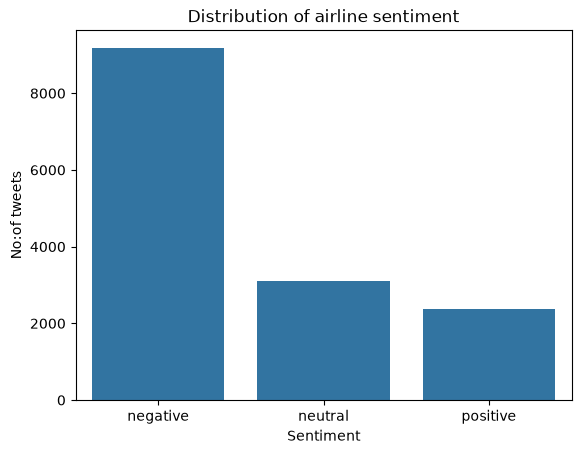

In [40]:
plt.title('Distribution of airline sentiment')
plt.xlabel('Sentiment')
plt.ylabel("No:of tweets")
sns.barplot(df_target)
plt.show()


Target variable is highly imbalanced as positive tweets are very low compared to negative & neutral tweets

In [41]:
#understanding the number of airlines and the tweets related to each airlines
df['airline'].value_counts()

airline
United            3822
US Airways        2913
American          2759
Southwest         2420
Delta             2222
Virgin America     504
Name: count, dtype: int64

tweets regarding 6 airlines are in the dataset

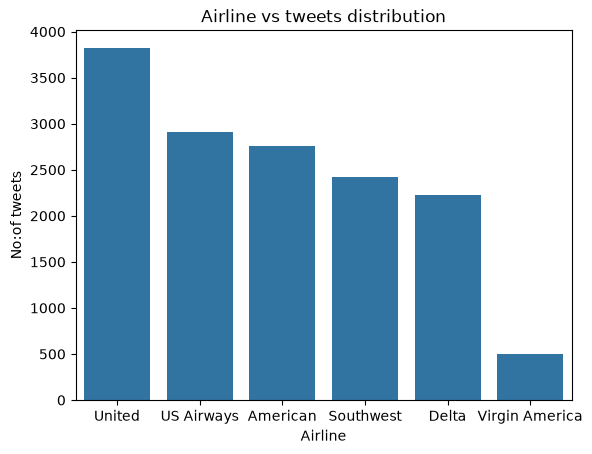

In [45]:
#visualising 
plt.title("Airline vs tweets distribution")
plt.xlabel('Airline')
plt.ylabel("No:of tweets")
sns.barplot(df['airline'].value_counts())
plt.show()

The dataset contains tweets related to six airlines. Among them, United has the highest number of tweets, while Virgin America has the lowest.

In [97]:
#Understanding the sentiment flow for each airlines
airline_sentiment=pd.crosstab(df['airline'],df['airline_sentiment'])
airline_sentiment

airline_sentiment,negative,neutral,positive
airline,,,
American,1960,463,336
Delta,955,723,544
Southwest,1186,664,570
US Airways,2263,381,269
United,2633,697,492
Virgin America,181,171,152


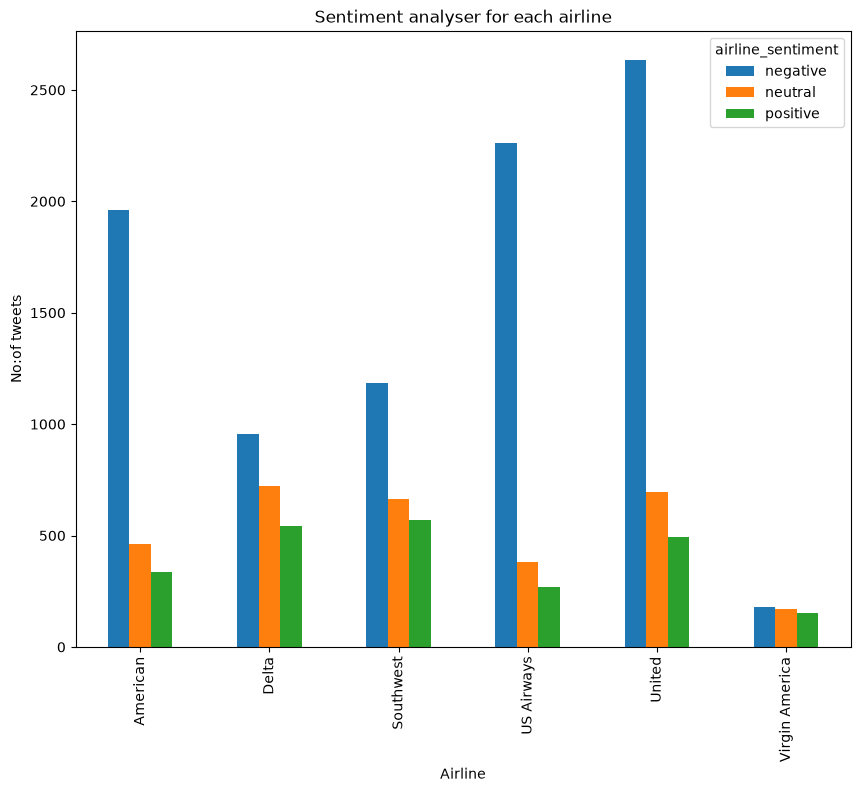

In [98]:
#visualising
airline_sentiment.plot(kind='bar',figsize=(10,8))
plt.title('Sentiment analyser for each airline')

plt.xlabel('Airline')
plt.ylabel('No:of tweets')

plt.show()

In [99]:
# Undertsnding the percentage distribution of sentiment for each airline
airline_sentiment['total']=np.sum(airline_sentiment,axis=1)
airline_sentiment[['negative%','neutral%','positive%']]=round((airline_sentiment[['negative','neutral','positive']].div(airline_sentiment['total'],axis=0)*100),2)
airline_sentiment

airline_sentiment,negative,neutral,positive,total,negative%,neutral%,positive%
airline,,,,,,,
American,1960,463,336,2759,71.04,16.78,12.18
Delta,955,723,544,2222,42.98,32.54,24.48
Southwest,1186,664,570,2420,49.01,27.44,23.55
US Airways,2263,381,269,2913,77.69,13.08,9.23
United,2633,697,492,3822,68.89,18.24,12.87
Virgin America,181,171,152,504,35.91,33.93,30.16


1) US Airways has the highest proportion of negative tweets, with 77.69% of its total tweets classified as negative.
2) Virgin America has the least proportion of negative tweets amongs all 6 airlines
3) United has the highest tweet volume but not the highest negative percentage


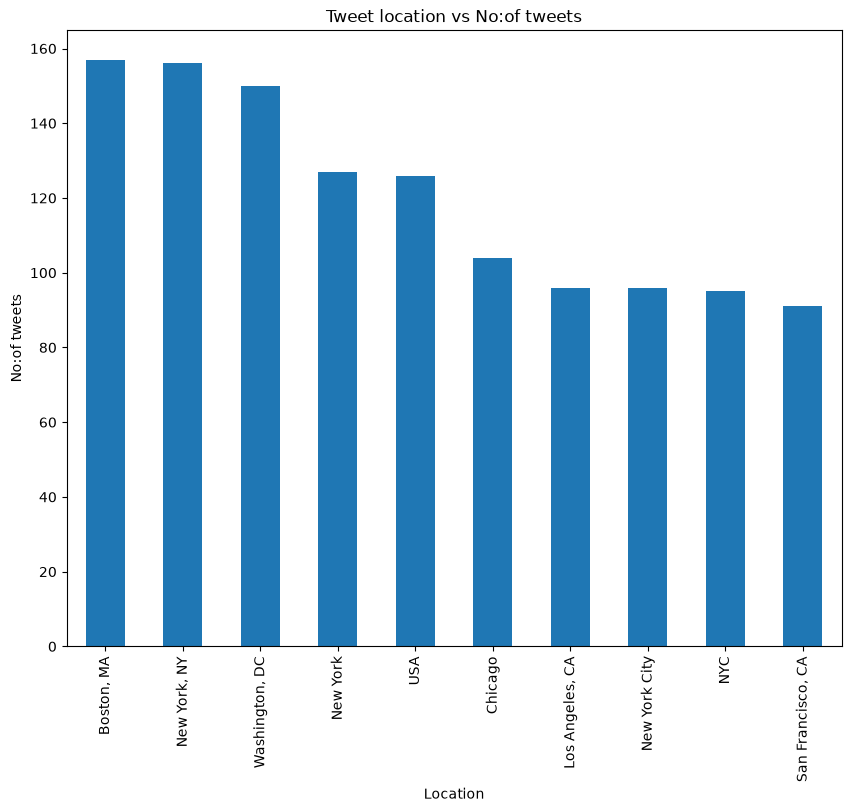

In [114]:
#Understnding the locations of tweetd
df['tweet_location'].value_counts().sort_values(ascending=False).head(10).plot(kind='bar',figsize=(10,8))
plt.title("Tweet location vs No:of tweets")
plt.xlabel('Location')
plt.ylabel('No:of tweets')
plt.show()



Same place have been entered as multiple names in the dataset- So the data was entered as free hand text by the user. Need to stardardize the names in the preprocessing stage

In [126]:
#understading the reason for negative sentiment for each airline
df_negative=df[df['negativereason'].notna()]
df_negaitve_reason=pd.crosstab(df_negative['airline'],df['negativereason'])
df_negaitve_reason

negativereason,Bad Flight,Can't Tell,Cancelled Flight,Customer Service Issue,Damaged Luggage,Flight Attendant Complaints,Flight Booking Problems,Late Flight,Lost Luggage,longlines
airline,,,,,,,,,,
American,87,198,246,768,12,87,130,249,149,34
Delta,64,186,51,199,11,60,44,269,57,14
Southwest,90,159,162,391,14,38,61,152,90,29
US Airways,104,246,189,811,11,123,122,453,154,50
United,216,379,181,681,22,168,144,525,269,48
Virgin America,19,22,18,60,4,5,28,17,5,3


In [124]:
pd.crosstab(df_negative['airline'],df['negativereason'])

negativereason,Bad Flight,Can't Tell,Cancelled Flight,Customer Service Issue,Damaged Luggage,Flight Attendant Complaints,Flight Booking Problems,Late Flight,Lost Luggage,longlines
airline,,,,,,,,,,
American,87,198,246,768,12,87,130,249,149,34
Delta,64,186,51,199,11,60,44,269,57,14
Southwest,90,159,162,391,14,38,61,152,90,29
US Airways,104,246,189,811,11,123,122,453,154,50
United,216,379,181,681,22,168,144,525,269,48
Virgin America,19,22,18,60,4,5,28,17,5,3


In [133]:
reason_pct=pd.crosstab(df_negative['airline'],df_negative['negativereason'],normalize='index')*100
reason_pct=np.round(reason_pct,2)
reason_pct


negativereason,Bad Flight,Can't Tell,Cancelled Flight,Customer Service Issue,Damaged Luggage,Flight Attendant Complaints,Flight Booking Problems,Late Flight,Lost Luggage,longlines
airline,,,,,,,,,,
American,4.44,10.10,12.55,39.18,0.61,4.44,6.63,12.70,7.60,1.73
Delta,6.70,19.48,5.34,20.84,1.15,6.28,4.61,28.17,5.97,1.47
Southwest,7.59,13.41,13.66,32.97,1.18,3.20,5.14,12.82,7.59,2.45
US Airways,4.60,10.87,8.35,35.84,0.49,5.44,5.39,20.02,6.81,2.21
United,8.20,14.39,6.87,25.86,0.84,6.38,5.47,19.94,10.22,1.82
Virgin America,10.50,12.15,9.94,33.15,2.21,2.76,15.47,9.39,2.76,1.66


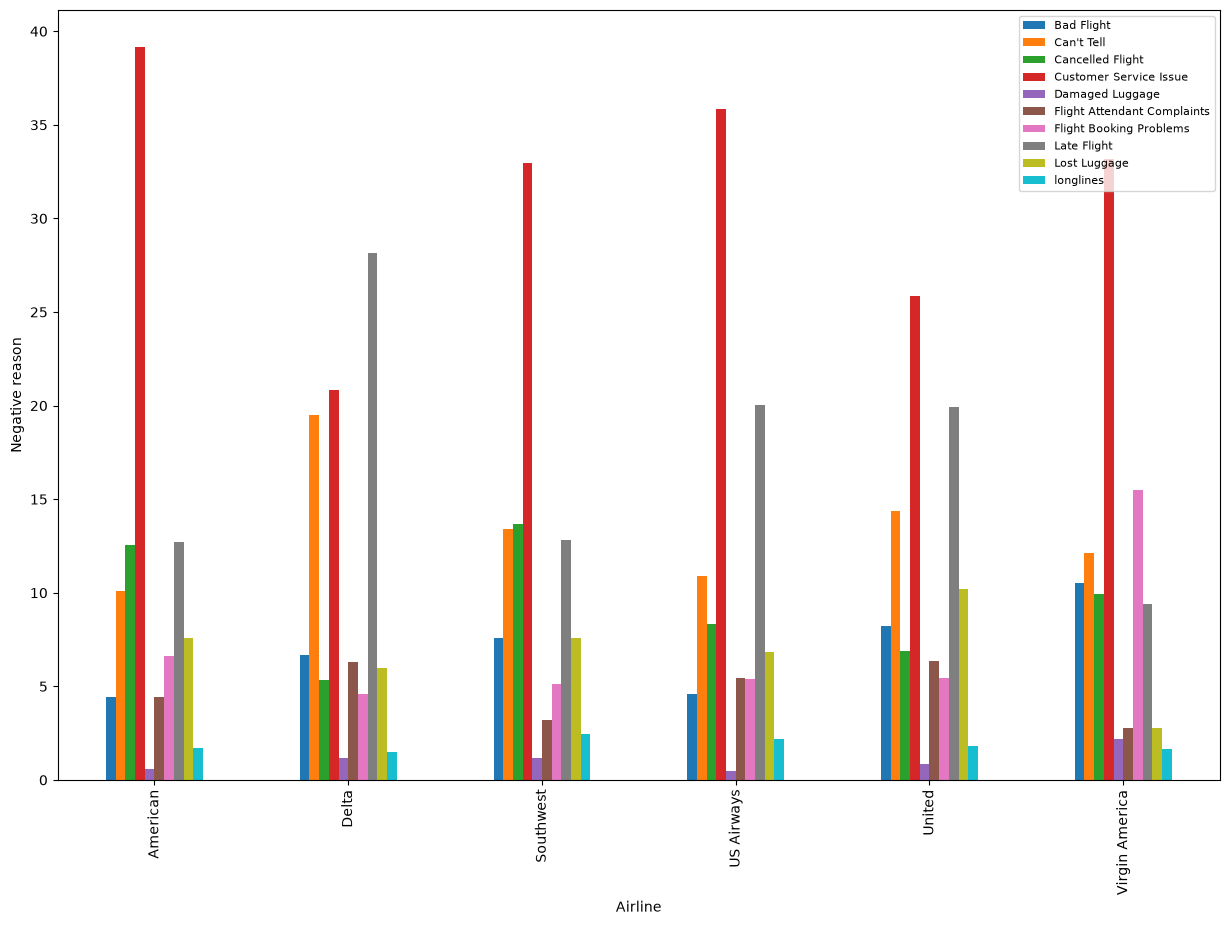

In [226]:
reason_pct.plot(kind='bar',figsize=(15,10))
plt.xlabel('Airline')
plt.ylabel('Negative reason')
plt.legend(loc='upper right',fontsize=8)
plt.show()

1) For majority of the airlines, customer service appears to the biggest issue
2) In Delta flight, the main issue is Late flights

In [ ]:
# understanding sentiment with re-tweets
df.groupby('airline_sentiment')['retweet_count'].mean()

airline_sentiment
negative    0.093375
neutral     0.060987
positive    0.069403
Name: retweet_count, dtype: float64

Negative tweets are re-tweeted more than positive or neutral

#Tweet exploration


In [169]:
df['char_count']=df['text'].str.len()
df['word_count']=df['text'].str.split(" ").str.len()
df

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone,char_count,word_count
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada),35,4
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada),72,9
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada),71,12
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada),126,17
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada),55,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14635,569587686496825344,positive,0.3487,NaN,0.0000,American,NaN,KristenReenders,NaN,0,@AmericanAir thank you we got on a different f...,NaN,2015-02-22 12:01:01 -0800,NaN,NaN,63,11
14636,569587371693355008,negative,1.0000,Customer Service Issue,1.0000,American,NaN,itsropes,NaN,0,@AmericanAir leaving over 20 minutes Late Flig...,NaN,2015-02-22 11:59:46 -0800,Texas,NaN,150,23
14637,569587242672398336,neutral,1.0000,NaN,NaN,American,NaN,sanyabun,NaN,0,@AmericanAir Please bring American Airlines to...,NaN,2015-02-22 11:59:15 -0800,"Nigeria,lagos",NaN,60,7
14638,569587188687634433,negative,1.0000,Customer Service Issue,0.6659,American,NaN,SraJackson,NaN,0,"@AmericanAir you have my money, you change my ...",NaN,2015-02-22 11:59:02 -0800,New Jersey,Eastern Time (US & Canada),135,23


In [ ]:
df_positive=df[df['airline_sentiment']=='positive']
df_neutral=df[df['airline_sentiment']=='neutral']
df_negative=df[df['airline_sentiment']=='negative']

In [ ]:
#understanding the text len pattern for negative, neutral and positve tweets
print(f'The avg character lengths of negative tweets = {df_negative['char_count'].mean()} and word lengths={df_negative['word_count'].mean()}')
print(f'The avg character lengths of positve tweets = {df_positive['char_count'].mean()} and word lengths={df_positive['word_count'].mean()}')
print(f'The avg character lengths of neutral tweets = {df_neutral['char_count'].mean()} and word lengths={df_neutral['word_count'].mean()}')

The avg character lengths of negative tweets = 113.9479189365875 and word lengths=19.84451950315973
The avg character lengths of positve tweets = 86.08294540837917 and word lengths=14.138383410918324
The avg character lengths of neutral tweets = 87.3594707970313 and word lengths=14.515650209745079


The negative tweets tends to  have more word word count and character count compared to neutral and postive. The possible reason might be that people like to explain there complaints/issues in detail

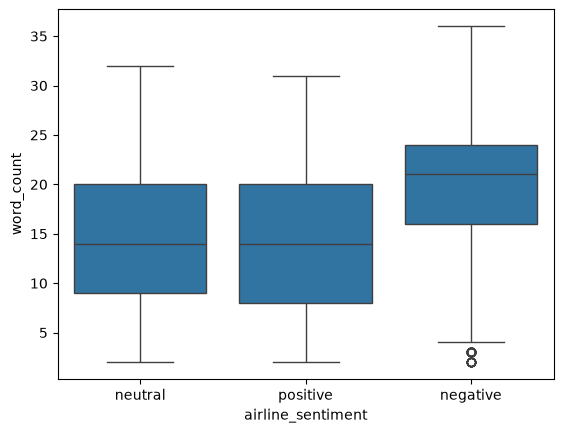

In [185]:
sns.boxplot(data=df,x='airline_sentiment',y='word_count')
plt.show()

In [191]:
#converting tweet created to date
df['tweet_created']=pd.to_datetime(df['tweet_created'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype                    
---  ------                        --------------  -----                    
 0   tweet_id                      14640 non-null  int64                    
 1   airline_sentiment             14640 non-null  str                      
 2   airline_sentiment_confidence  14640 non-null  float64                  
 3   negativereason                9178 non-null   str                      
 4   negativereason_confidence     10522 non-null  float64                  
 5   airline                       14640 non-null  str                      
 6   airline_sentiment_gold        40 non-null     str                      
 7   name                          14640 non-null  str                      
 8   negativereason_gold           32 non-null     str                      
 9   retweet_count                 14640 non-null  int6

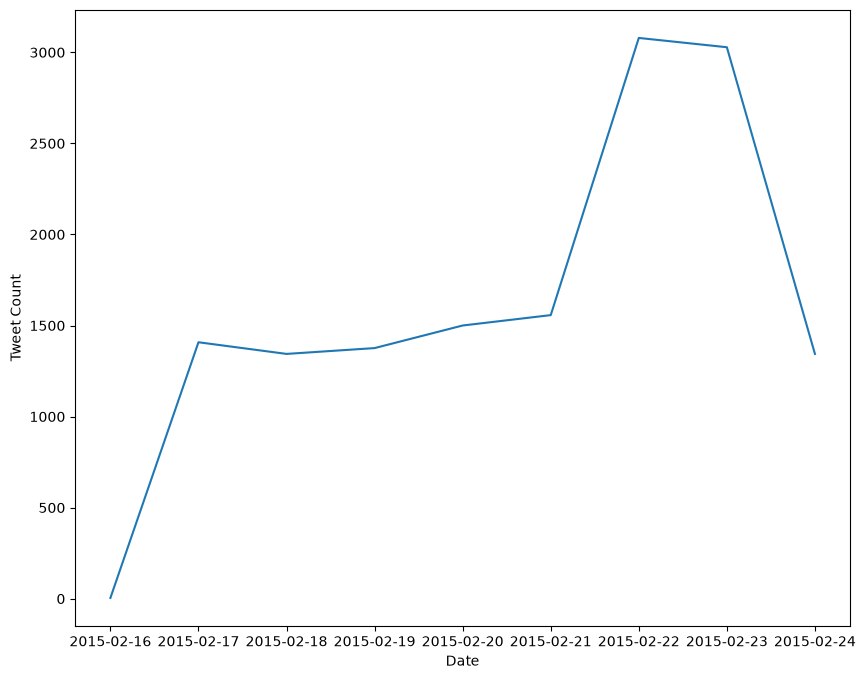

In [223]:
tweets_date=df.groupby([df['tweet_created'].dt.date]).size()
tweets_date.plot(kind='line',figsize=(10,8))

plt.xlabel('Date')
plt.ylabel('Tweet Count')
plt.show()


In [219]:
print(type(plt.xlabel))

<class 'str'>


Tweet activity increased sharply on February 22–23 compared with the previous days, indicating a significant spike in discussion during that period.

In [ ]:
#checking which sentimet had lead to spike 22nd to 23rd Feb
pd.crosstab(df['tweet_created'].dt.date,df['airline_sentiment'])

airline_sentiment,negative,neutral,positive
tweet_created,,,
2015-02-16,3,1,0
2015-02-17,838,297,273
2015-02-18,736,335,273
2015-02-19,751,329,296
2015-02-20,835,383,282
2015-02-21,1049,278,230
2015-02-22,2266,463,350
2015-02-23,1919,676,433
2015-02-24,781,337,226


Negative sentiment increased considerably between 21st to 23rd Feb

In [206]:
pd.crosstab(df['tweet_created'].dt.date,df['airline'])

airline,American,Delta,Southwest,US Airways,United,Virgin America
tweet_created,,,,,,
2015-02-16,0,2,0,0,2,0
2015-02-17,0,263,384,311,396,54
2015-02-18,1,268,292,317,406,60
2015-02-19,1,283,317,279,426,70
2015-02-20,1,251,319,333,526,70
2015-02-21,1,243,370,360,506,77
2015-02-22,988,408,279,648,703,53
2015-02-23,1141,391,276,488,641,91
2015-02-24,626,113,183,177,216,29


American is the main airline that caused the spike